# Explore here

In [3]:
# Your code here
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
from utils import db_connect

# load the .env file variables
load_dotenv()


True

1) DESCARGAR CONJUNTO DE DATOS 

In [4]:

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
#Almacena los datos en crudo en la carpeta ./data/raw.
df.to_csv("../data/raw/airbnb_data.csv", index = False)   #index=False evita que pandas guarde el índice del DataFrame en el archivo CSV.

'''
@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/raw (main) $ pwd
/workspaces/LC_machine-learning-python-template/data/raw
@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/raw (main) $ ls -lrt
total 6912
-rw-rw-rw- 1 vscode vscode 7077687 Feb  9 15:03 airbnb_data.csv
'''


'\n@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/raw (main) $ pwd\n/workspaces/LC_machine-learning-python-template/data/raw\n@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/raw (main) $ ls -lrt\ntotal 6912\n-rw-rw-rw- 1 vscode vscode 7077687 Feb  9 15:03 airbnb_data.csv\n'

2. EXPLORACIÓN Y LIMPIEZA DE DATOS

In [6]:
# Obtener las dimensiones
df.shape

(48895, 16)

In [7]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Una vez hemos obtenido esta información, es importante que seamos capaces de extraer conclusiones, como las siguientes:

* Existen un total de 48895  filas (en este caso, entradas registradas en airbnb) y 16 columnas.  
* la columna host_id nos puede dar una idea de la cantidad de veces que ese inmueble ha sido rentado.  
* La columna neighbourhood_group y neighbourhood, presenta los vecindarios mas cotizados o si queremos ver la cantidad de alquileres teniendo en cuenta el precio.  
* Con la latitud y longitud se puede dibujar un mapa donde se vean los puntos más y menos rentados segun este dataframe  
* Las variables  "last_review" (10052 nulls) y  "reviews_per_month" (10052 nulls), solo tienen 38843 filas con valores  
* 10 variables numericas: id, host_id, latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count and availability_365.  
* 6 variables categoricas: name, host_name, neighbourhood_group, neighbourhood, room_type and last_review.

ELIMINAR DUPLICADOS

In [8]:
df['id'].duplicated().sum()  # Variable única de registro

np.int64(0)

In [9]:
df['host_id'].duplicated().sum()  # Cantidad de registros por vivienda

np.int64(11438)

Teniendo en cuenta la entrada ID vemos que no hay valores duplicados

In [10]:
df.drop(["id", "name", "host_name", "last_review", "reviews_per_month"], axis = 1, inplace = True) # axis = 1 eliminar columnas; inplace = true, modifica el dataframe directamente. 
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


3.   Análisis de variables univariante

3.1 ANALISIS DE VARIABLES CATEGORICAS

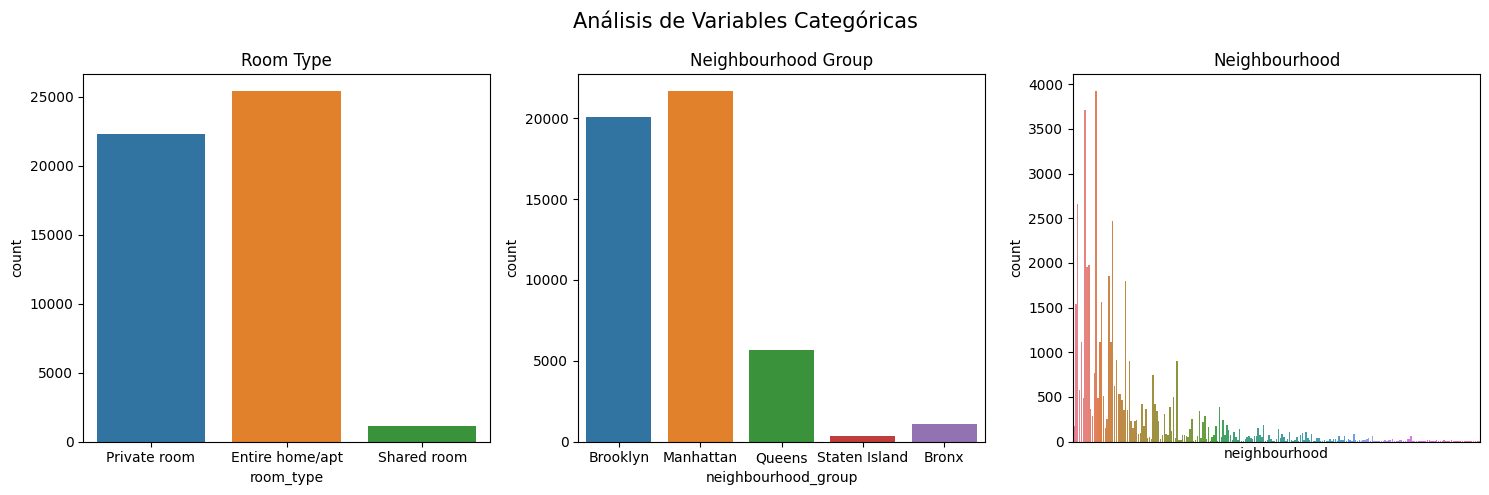

In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15,5))   #crea figura y rejilla (1 fila  x 3 columnas)
plt.suptitle('Análisis de Variables Categóricas', fontsize=15)


sns.countplot(ax= ax[0], data = df, x = "room_type", hue='room_type')  #ax = 0 se grafica en el primer subplot
ax[0].set_title("Room Type")

sns.countplot(ax = ax[1], data = df, x = "neighbourhood_group", hue='neighbourhood_group') #ax = 1 se grafica en el segundo subplot
ax[1].set_title("Neighbourhood Group")

sns.countplot(ax = ax[2], data = df, x = 'neighbourhood', hue='neighbourhood') #ax = 3 se grafica en el tercer subplot
ax[2].set_title("Neighbourhood")
plt.xticks(rotation=90, fontsize=6)
ax[2].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # esconde x-axis labels 

plt.tight_layout()  #Ajustar diseño para evitar solapamientos
plt.show()

Acorde a la gráfica podemos ver:

* Room Type: la mayoria de los usuarios tienen a alquilar habitaciones privadas o el alojamiento entero, esto tal vez debido a su comodidad y privacidad.
* Neighbourhood Group: Los alojamientos mas solicitados estan ubicados en la zonas de Brooklin y Manhattan. Manhattan por excelencia es el lumgar mejor comunicado a los principales lugares turisticos y tiene varidad de oferta gastronomica
Brooklyn, suele ser mas económico y esta bien comunicado en tren a los lugares turísticos. 

3.2 ANALISIS DE VARIABLES NUMÉRICAS

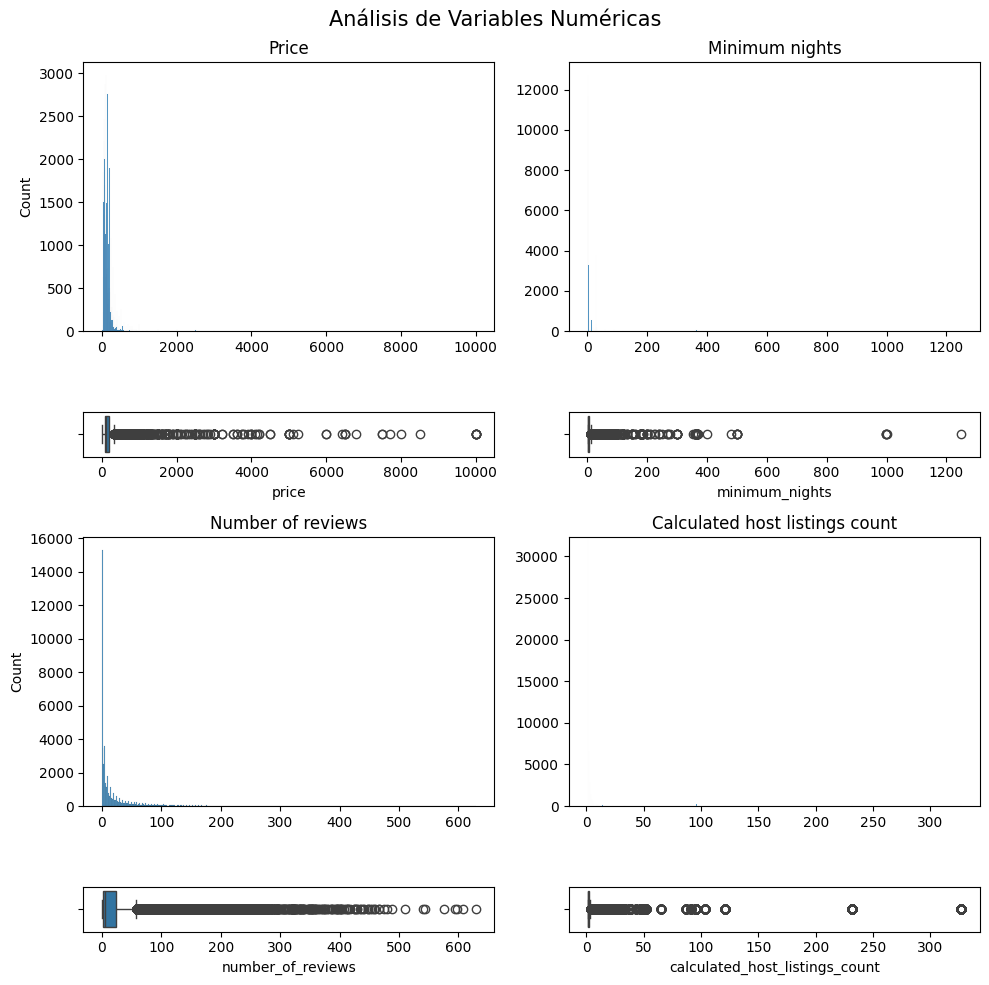

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(4, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1]})
plt.suptitle('Análisis de Variables Numéricas', fontsize=15)

# Crear un histograma múltiple

# Price
sns.histplot(ax=ax[0, 0], data=df, x="price").set(xlabel=None, title="Price")
sns.boxplot(ax=ax[1, 0], data=df, x="price")

# Minimum Nights
sns.histplot(ax=ax[0, 1], data=df, x="minimum_nights").set(xlabel=None, ylabel=None, title="Minimum nights")
sns.boxplot(ax=ax[1, 1], data=df, x="minimum_nights")

# Number of Reviews
sns.histplot(ax=ax[2, 0], data=df, x="number_of_reviews").set(xlabel=None, title="Number of reviews")
sns.boxplot(ax=ax[3, 0], data=df, x="number_of_reviews")

# Calculated Host Listings Count
sns.histplot(ax=ax[2, 1], data=df, x="calculated_host_listings_count").set(xlabel=None, ylabel=None, title="Calculated host listings count")
ax[2, 1].set_ylim(0, df["calculated_host_listings_count"].value_counts().max())  # Ajustar eje Y
sns.boxplot(ax=ax[3, 1], data=df, x="calculated_host_listings_count")


# Adjust the layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

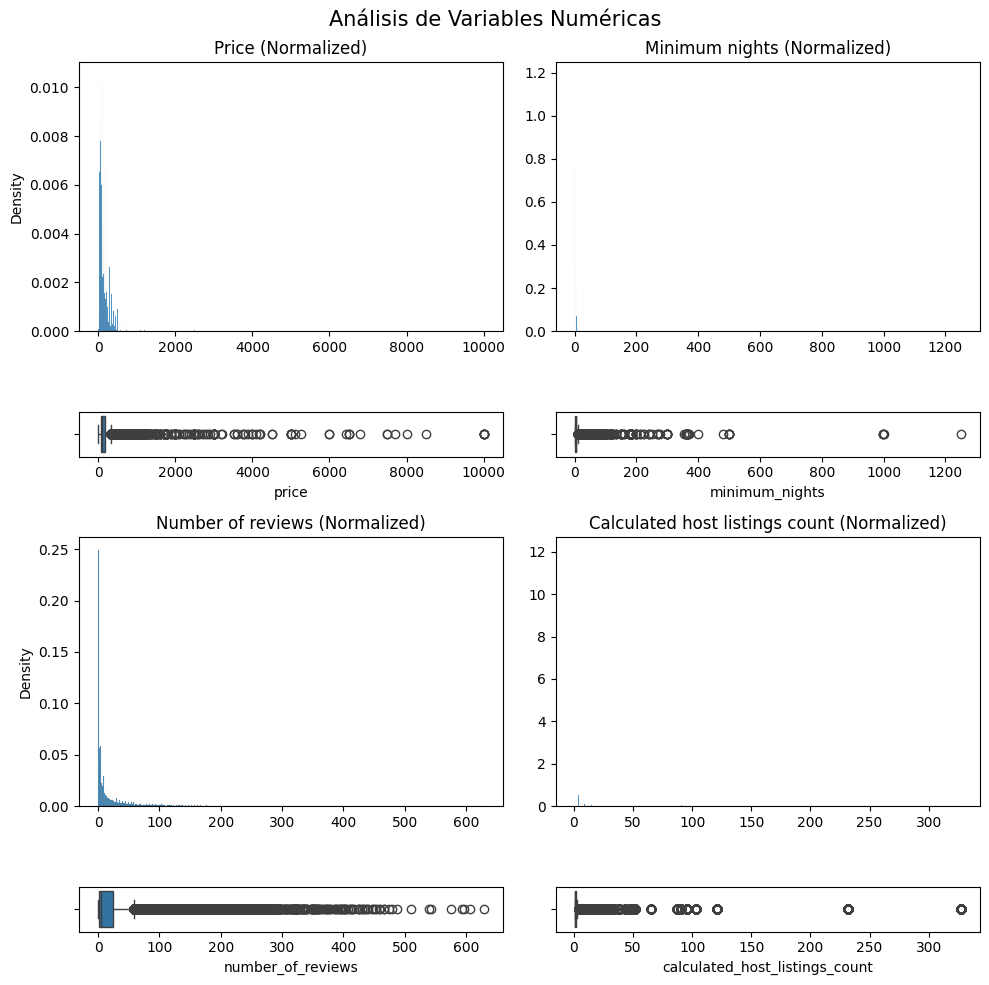

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(4, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1]})
plt.suptitle('Análisis de Variables Numéricas', fontsize=15)

# Crear un histograma múltiple con normalización

# Price
sns.histplot(ax=ax[0, 0], data=df, x="price", stat="density").set(xlabel=None, title="Price (Normalized)") #stat="density" normaliza el histograma para que el área total sume 1
sns.boxplot(ax=ax[1, 0], data=df, x="price")

# Minimum Nights
sns.histplot(ax=ax[0, 1], data=df, x="minimum_nights", stat="density").set(xlabel=None, ylabel=None, title="Minimum nights (Normalized)")
sns.boxplot(ax=ax[1, 1], data=df, x="minimum_nights")

# Number of Reviews
sns.histplot(ax=ax[2, 0], data=df, x="number_of_reviews", stat="density").set(xlabel=None, title="Number of reviews (Normalized)")
sns.boxplot(ax=ax[3, 0], data=df, x="number_of_reviews")

# Calculated Host Listings Count
sns.histplot(ax=ax[2, 1], data=df, x="calculated_host_listings_count", stat="density").set(xlabel=None, ylabel=None, title="Calculated host listings count (Normalized)")
sns.boxplot(ax=ax[3, 1], data=df, x="calculated_host_listings_count")

# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

ANÁLISIS VARIABLES NUMÉRICAS: 

* PRECIO: La mayoria de hospedajes cobran precios asequibles, aun asi hay unos cuantas opciones de lujo con precios elevados
* MÍNIMO DE NOCHES: Los anfitriones no exigen por lo general un numero de noches elevado, lo que permite que haya facilidad en el alquiler
* NÚMERO DE VALORACIONRES:La mayporia de hospedajes tienen pocas o ninguna valoración, asumiendo que sean nuevas o que no se icentive del modo adecuado a los clientes a dejar alguna valoración
* RECUENTO DE ANFITRIONES: Por lo general los anfitriones tienen una o pocas propiedades a su nombre, esto vale para determinar el nivel de experiencia en este tipo de negocio y su consolidación en el mismo. 

4. Análisis de variables multivariante


4.1 Análisis numérico-numérico


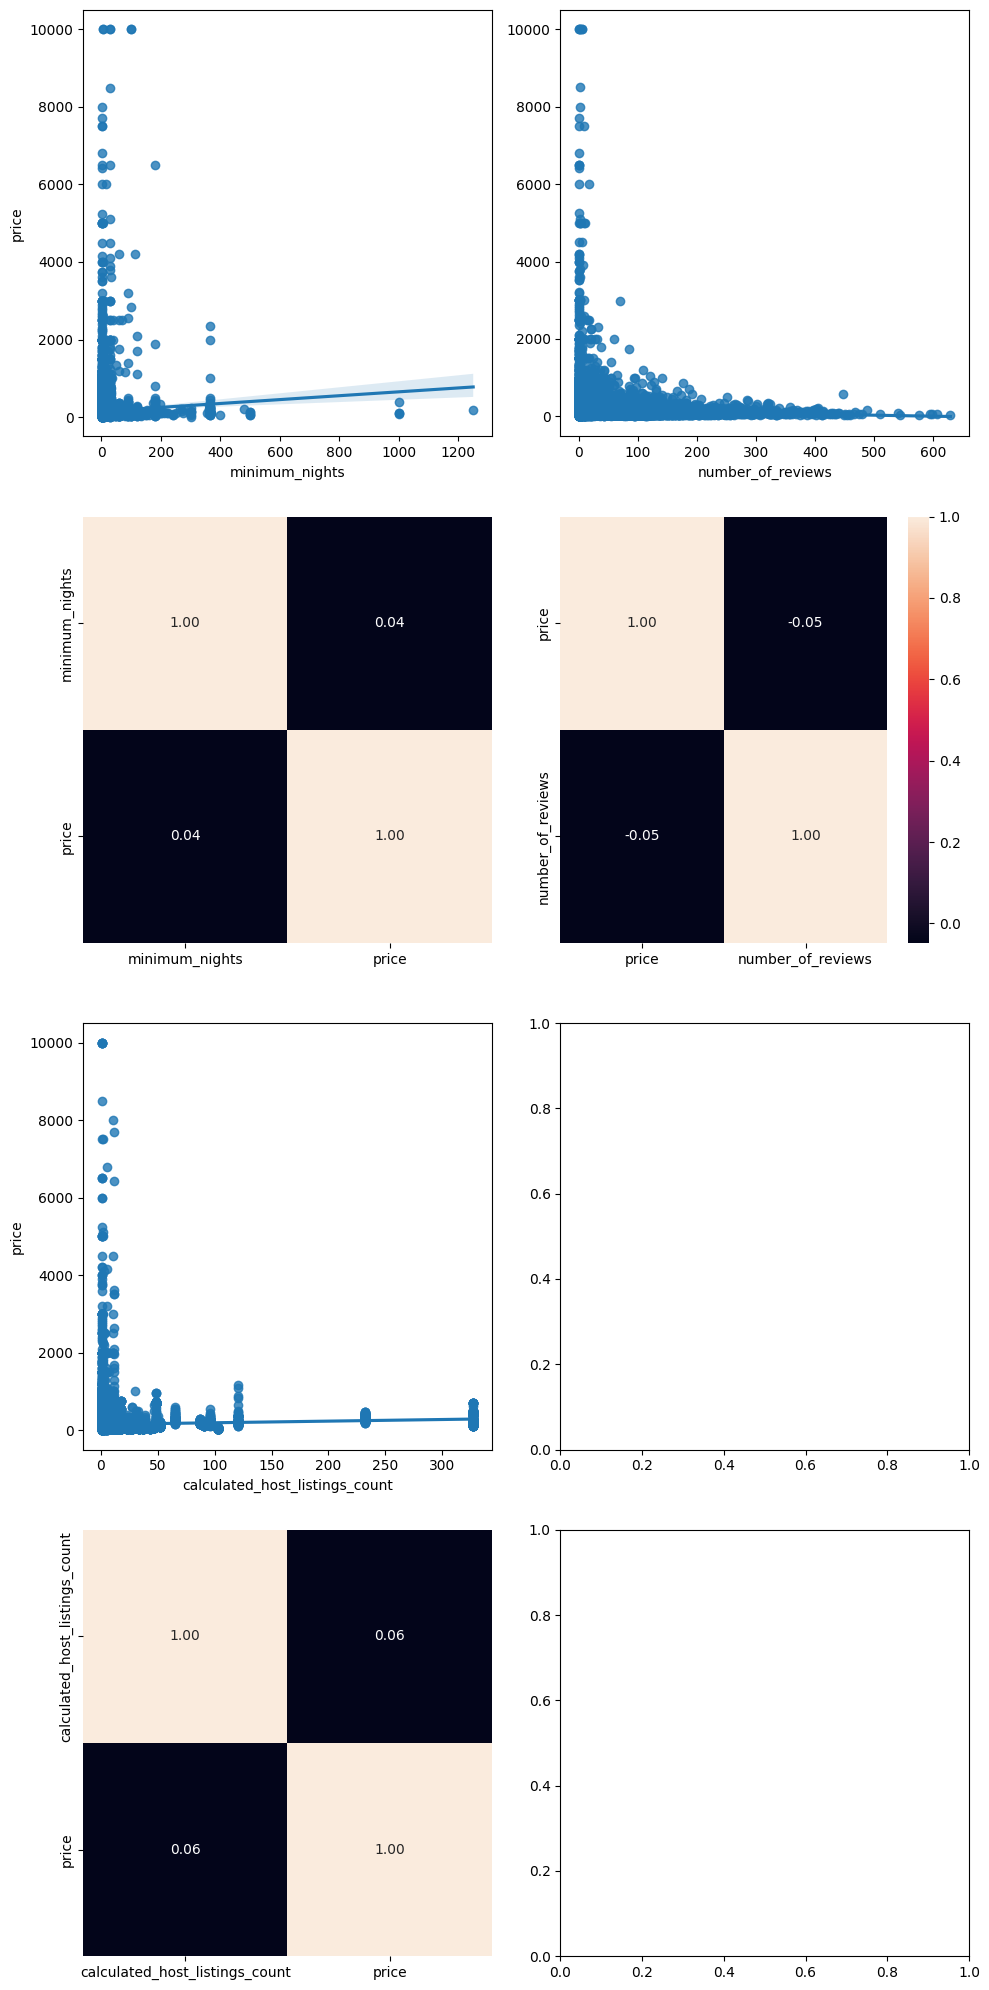

In [14]:
fig, ax = plt.subplots(4, 2, figsize = (10, 20))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = ax[0, 0], data = df, x = "minimum_nights", y = "price")
sns.heatmap(df[["minimum_nights", "price"]].corr(), annot = True, fmt = ".2f", ax = ax[1, 0], cbar = False)

sns.regplot(ax = ax[0, 1], data = df, x = "number_of_reviews", y = "price").set(ylabel=None)
sns.heatmap(df[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = ax[1, 1])

sns.regplot(ax = ax[2, 0], data = df, x = "calculated_host_listings_count", y = "price")
sns.heatmap(df[["calculated_host_listings_count", "price"]].corr(), annot = True, fmt = ".2f", ax = ax[3, 0], cbar = False)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

No hay correlación sustancial entre el precio con ninguna de las otras variables. 

4.2 Análisis categórico-categórico


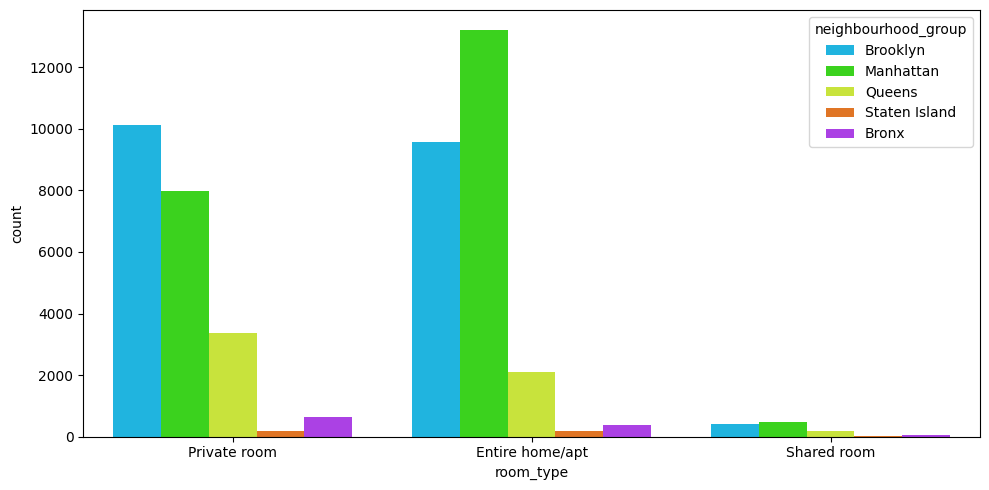

In [15]:
fig, ax = plt.subplots(figsize = (10, 5))

sns.countplot(data = df, x = "room_type", hue = "neighbourhood_group", palette='gist_ncar')
plt.tight_layout()
plt.show()

Del grafico podemos obtener las siguientes conclusiones: 

* Manhatan es la zona masapetecida por los clientes, y lo que mas alquilan son espacios completos, aunque los cuardos privados tambien son una buena opcion. 
* Brooklyn tanto los cuardos privados como los pisos enteros son igual de demandados ademas como segunda opcion de alquiler esta casi a la par que Manhatan. 
* Staten Islan y el Bronx no son zonas concurridas ni demandadas para alquiler vacacional en ninguna de sus presentaciones. 
* Es minima la cantidad de alquileres que se hacen para habitaciones compartidas, dando por hecho que es mas una opción comodín de alojamiento que una opción de negocio. 
 

Combinaciones de la clase con varias predictoras

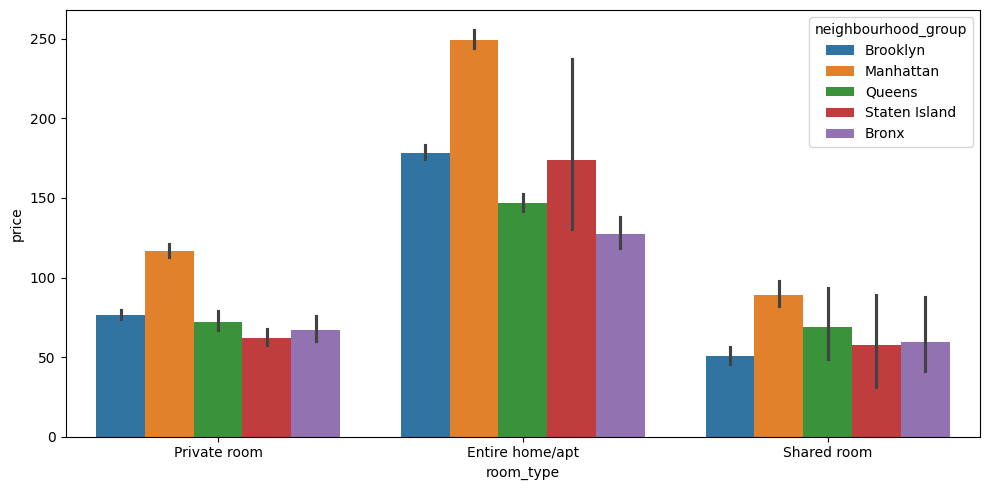

In [16]:
fig = plt.subplots(figsize = (10, 5))

sns.barplot(data = df, x = "room_type", y = "price", hue = "neighbourhood_group")

plt.tight_layout()

plt.show()

Analisis: 

* Independientemente del tipo de alojamiento, todos los vecindarios presentan la misma proporcionalidad en cuanto a diferencias de precio. 
* Excepto Manhatan, el precio por tipo de alojamiento parece rondar el mismo precio, aun asi sólo Manhatan y Brooklyn tienen la mayoria de solicitudes, tal vez debido a la cercania a lugares de interés, comunicación u otros factores.
* Manhatan se puede permitir elevar sus precios por un tercio o la mitad de precio que las otras zonas, y se aun asi la mas solitada de las 5 zonas.  

Análisis de correlaciones


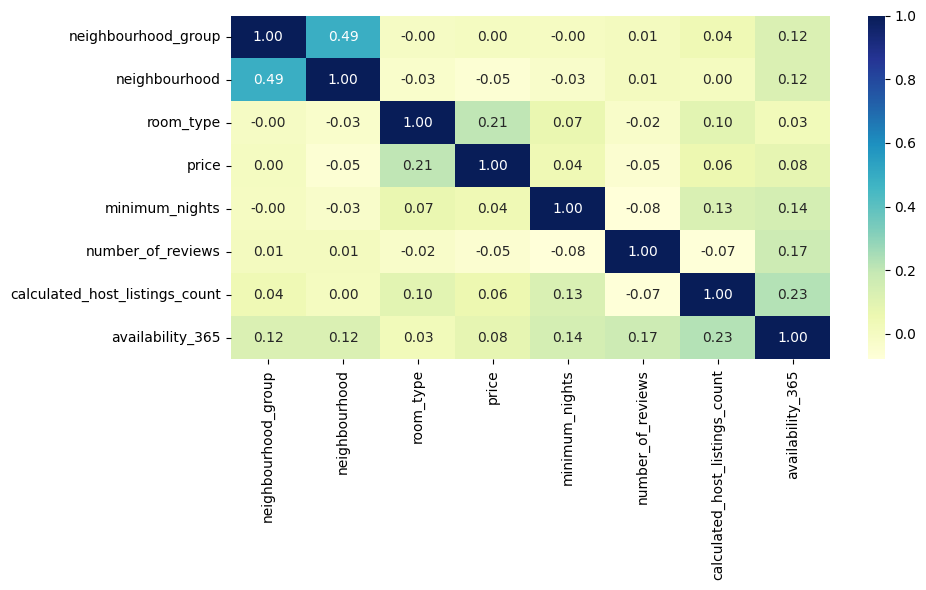

In [17]:
df["room_type"] = pd.factorize(df["room_type"])[0]
df["neighbourhood_group"] = pd.factorize(df["neighbourhood_group"])[0]
df["neighbourhood"] = pd.factorize(df["neighbourhood"])[0]

fig, ax = plt.subplots(figsize = (10, 6))

sns.heatmap(df[["neighbourhood_group", "neighbourhood", "room_type", "price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365"]].corr(), cmap="YlGnBu", annot = True, fmt = ".2f")

plt.tight_layout()

# Draw Plot
plt.show()

No hay una correlación fuerte entre las variables, aun asi podemos ver algo como que el precio esta ligado al tipo de habitación y posiblemente la disponibilidad del hospedaje sea un factor positivo para las reviews de los clientes

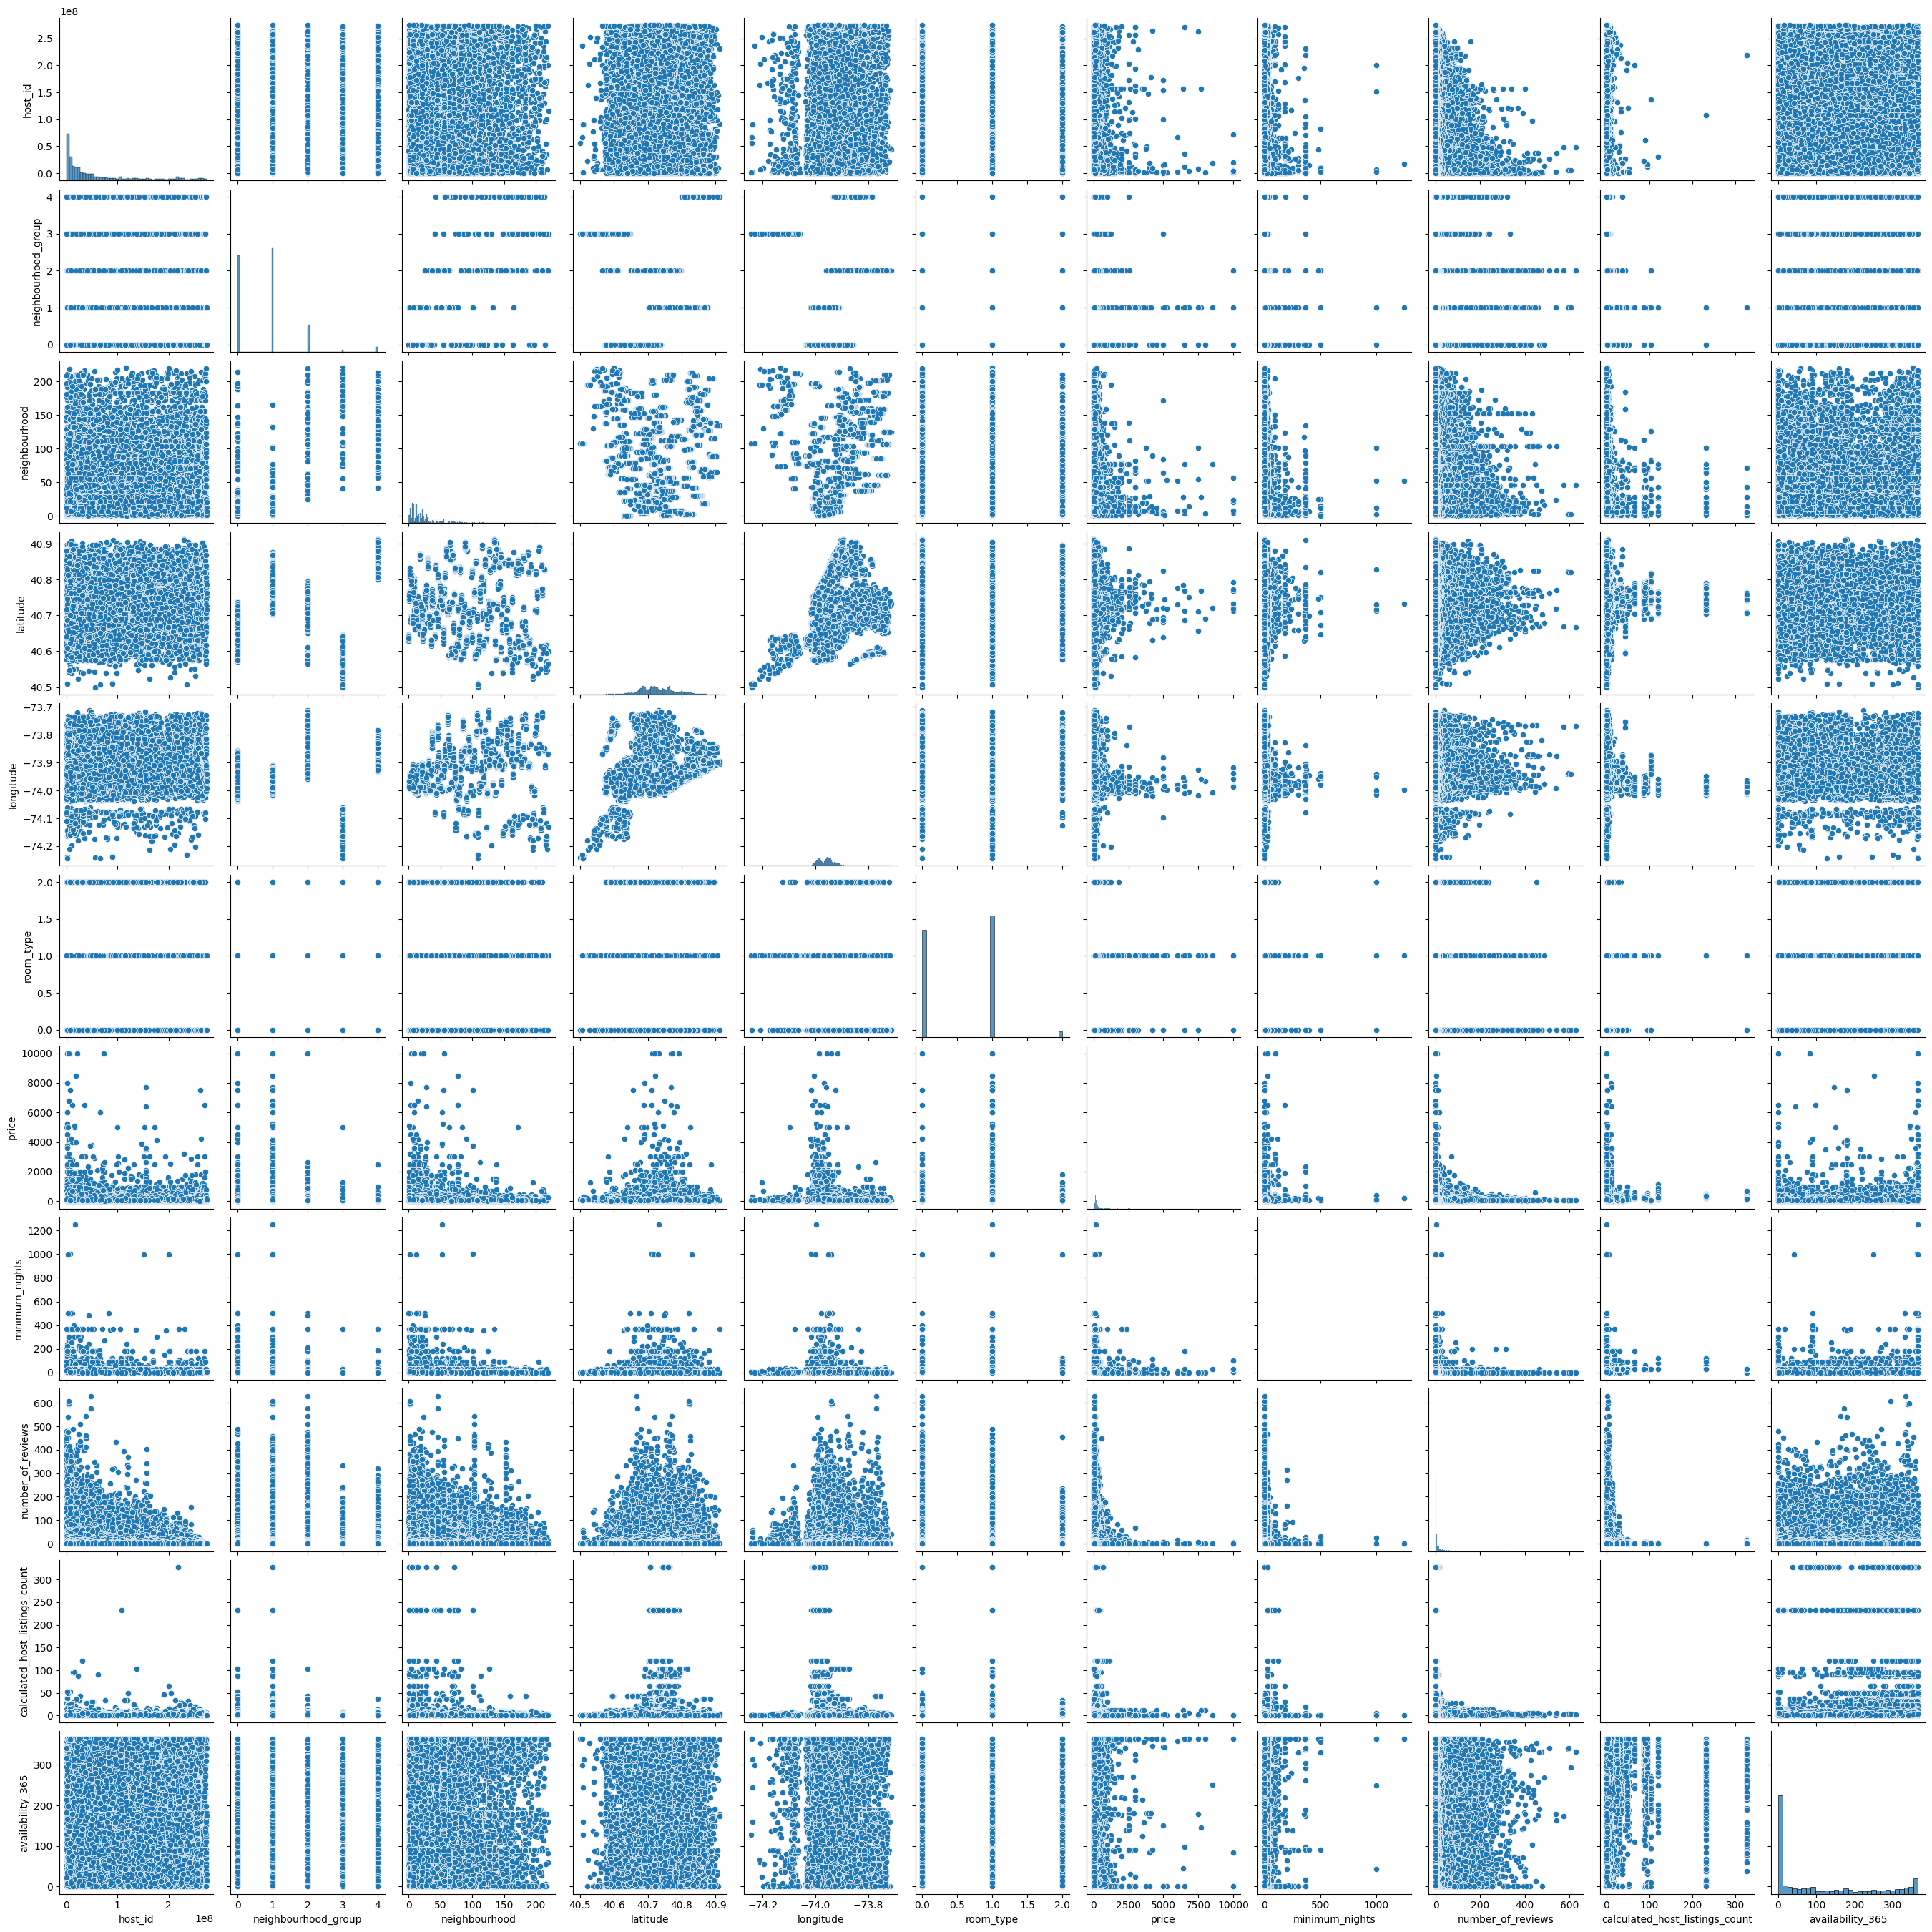

In [18]:
sns.pairplot(data = df)


Análisis de outliers


In [19]:
df.describe()


,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,0.786911,29.888782,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,7.143982,112.781327
std,7.861097e+07,0.844386,34.676634,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,32.952519,131.622289
min,2.438000e+03,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,7.822033e+06,0.000000,7.500000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,1.000000,0.000000
50%,3.079382e+07,1.000000,19.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.074344e+08,1.000000,37.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.000000,227.000000
max,2.743213e+08,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,327.000000,365.000000


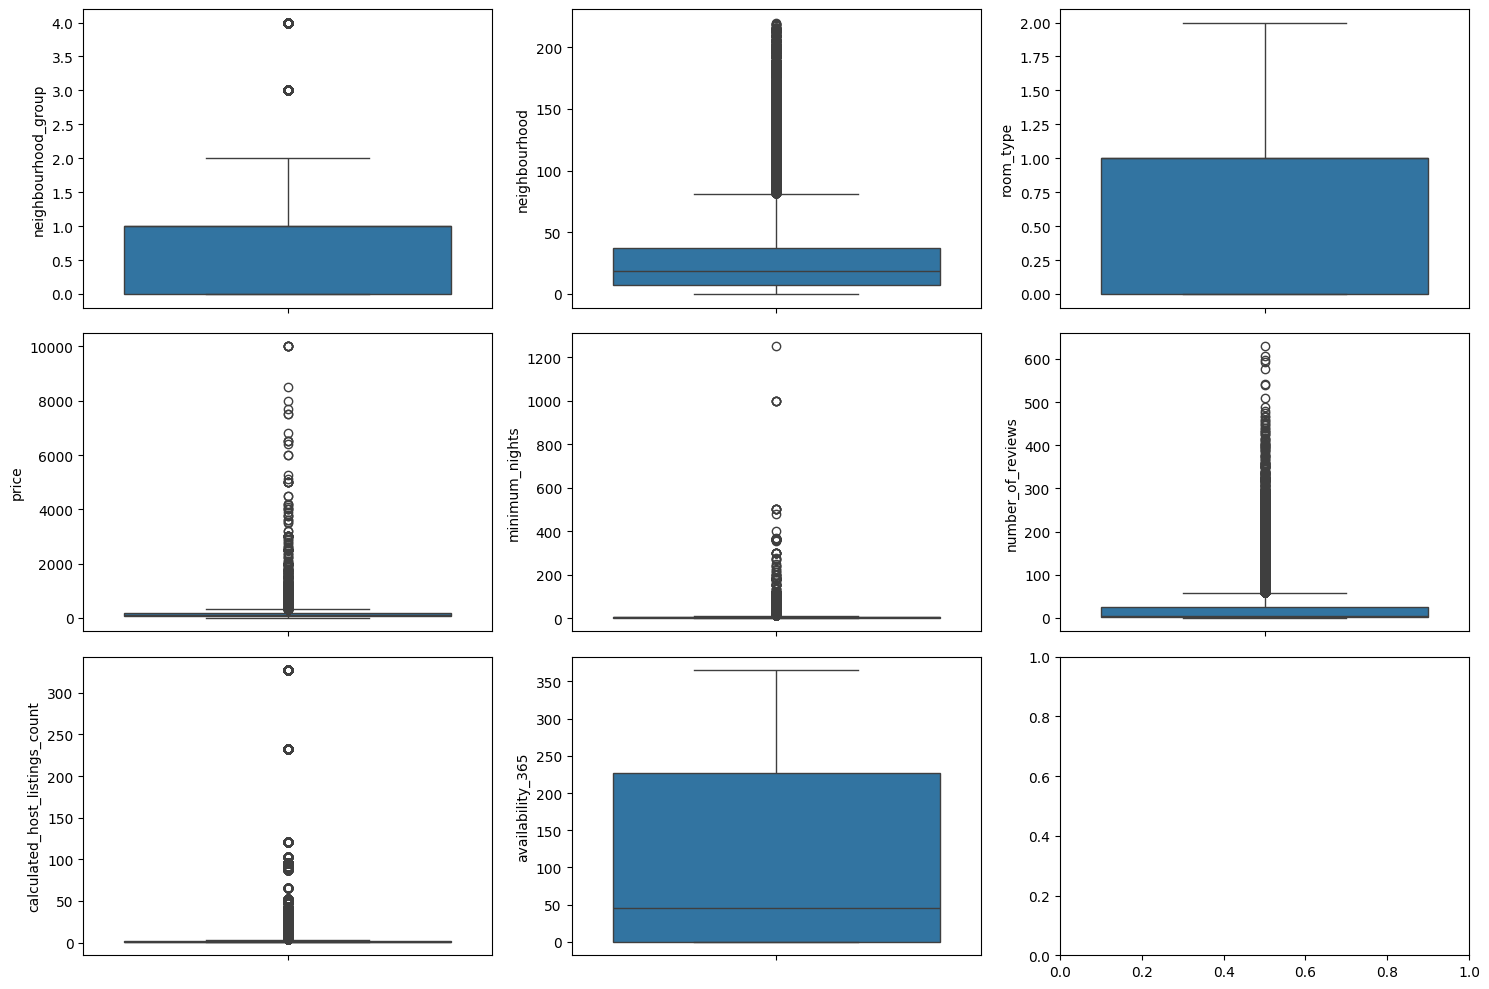

In [20]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = df, y = "neighbourhood_group")
sns.boxplot(ax = axis[0, 1], data = df, y = "neighbourhood")
sns.boxplot(ax = axis[0, 2], data = df, y = "room_type")
sns.boxplot(ax = axis[1, 0], data = df, y = "price")
sns.boxplot(ax = axis[1, 1], data = df, y = "minimum_nights")
sns.boxplot(ax = axis[1, 2], data = df, y = "number_of_reviews")
sns.boxplot(ax = axis[2, 0], data = df, y = "calculated_host_listings_count")
sns.boxplot(ax = axis[2, 1], data = df, y = "availability_365")

plt.tight_layout()

plt.show()

Outlier de la variable Precio


In [21]:
#Outlier de la variable Precio

price_stats = df["price"].describe()
price_stats


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [22]:
price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(price_stats, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de count    48895.00
mean       152.72
std        240.15
min          0.00
25%         69.00
50%        106.00
75%        175.00
max      10000.00
Name: price, dtype: float64


In [23]:
# Limpiar outliers

df_limpio = df[df["price"] > 0] #Elimina registros donde el precio (price) es igual a 0, ya que los precios no pueden ser negativos o cero
count_0 = df_limpio[df_limpio["price"] == 0].shape[0]
count_1 = df_limpio[df_limpio["price"] == 1].shape[0]
print("Count of 0: ", count_0)
print("Count of 1: ", count_1)


Count of 0:  0
Count of 1:  0


Outlier de la variable minimum_nights


In [24]:
nights_stats = df["minimum_nights"].describe()
nights_stats

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [25]:
nights_iqr = nights_stats["75%"] - nights_stats["25%"]
upper_limit = nights_stats["75%"] + 1.5 * nights_iqr
lower_limit = nights_stats["25%"] - 1.5 * nights_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(nights_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 11.0 y -5.0, con un rango intercuartílico de 4.0


In [27]:
df_limpio = df_limpio[df_limpio["minimum_nights"] <= 11]
count_0 = df_limpio[df_limpio["minimum_nights"] == 0].shape[0]
count_1 = df_limpio[df_limpio["minimum_nights"] == 1].shape[0]
count_2 = df_limpio[df_limpio["minimum_nights"] == 2].shape[0]
count_3 = df_limpio[df_limpio["minimum_nights"] == 3].shape[0]
count_4 = df_limpio[df_limpio["minimum_nights"] == 4].shape[0]


print("Count of 0: ", count_0)
print("Count of 1: ", count_1)
print("Count of 2: ", count_2)
print("Count of 3: ", count_3)
print("Count of 4: ", count_4)

Count of 0:  0
Count of 1:  12717
Count of 2:  11693
Count of 3:  7998
Count of 4:  3302


Outlier para  number_of_reviews


In [30]:
review_stats = df_limpio["number_of_reviews"].describe()
review_stats

count    42279.000000
mean        25.633577
std         46.683294
min          0.000000
25%          1.000000
50%          6.000000
75%         27.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [31]:
# IQR for number_of_reviews

review_iqr = review_stats["75%"] - review_stats["25%"]
upper_limit = review_stats["75%"] + 1.5 * review_iqr
lower_limit = review_stats["25%"] - 1.5 * review_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(review_iqr, 2)}")

The upper and lower limits for finding outliers are 66.0 and -38.0, with an interquartile range of 26.0


Dado que el numero de reviews no tiene una correlación fuerte con otras variables para nosotros no representa un factor decisivo para eliminar algun rango  

Outlier para  calculated_host_listings_count

In [33]:
# Stats for calculated_host_listings_count

hostlist_stats = df_limpio["calculated_host_listings_count"].describe()
hostlist_stats

count    42279.000000
mean         3.392346
std         21.961834
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [34]:
hostlist_iqr = hostlist_stats["75%"] - hostlist_stats["25%"]

upper_limit = hostlist_stats["75%"] + 1.5 * hostlist_iqr
lower_limit = hostlist_stats["25%"] - 1.5 * hostlist_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(hostlist_iqr, 2)}")

The upper and lower limits for finding outliers are 3.5 and -0.5, with an interquartile range of 1.0


In [36]:
count_04 = sum(1 for x in df_limpio["calculated_host_listings_count"] if x in range(0, 5))
count_1 = df_limpio[df_limpio["calculated_host_listings_count"] == 1].shape[0]
count_2 = df_limpio[df_limpio["calculated_host_listings_count"] == 2].shape[0]

print("Count of 0: ", count_04)
print("Count of 1: ", count_1)
print("Count of 2: ", count_2)

Count of 0:  39390
Count of 1:  29520
Count of 2:  6073


In [37]:
#Limpiar outliers
df_limpio = df_limpio[df_limpio["calculated_host_listings_count"] > 4]


Análisis de valores faltantes


In [41]:
df_limpio.isnull().sum().sort_values(ascending = False)



host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Escalado de valores

In [ ]:
# escalado mínimo-máximo varaiables numéricas
from sklearn.preprocessing import MinMaxScaler

num_variables = ["number_of_reviews", "minimum_nights", "calculated_host_listings_count","availability_365", "neighbourhood_group", "room_type"]

# Dividimos el conjunto de datos en muestras de train y test
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(df_limpio[num_variables])
df_scal = pd.DataFrame(scal_features, index = df_limpio.index, columns = num_variables)
df_scal["price"] = df_limpio["price"]
df_scal.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
0,0.016575,0.0,0.003106,1.000000,0.0,0.0,149
21,0.239411,0.1,0.003106,0.950685,0.0,0.0,130
22,0.071823,0.0,0.003106,0.997260,0.0,0.0,80
23,0.130755,0.1,0.003106,0.832877,0.0,0.0,110
92,0.029466,0.6,0.003106,0.506849,0.0,0.0,98


Selección de características

In [47]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

X = df_scal.drop("price", axis = 1)
y = df_scal["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,minimum_nights,calculated_host_listings_count,availability_365,room_type
0,0.3,0.006211,0.819178,0.0
1,0.0,0.000000,0.849315,0.0
2,0.1,0.000000,0.854795,0.5
3,0.0,0.012422,0.747945,0.0
4,0.1,1.000000,0.827397,0.5


SALVAR DATOS

In [48]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

'''
@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/processed (main) $ pwd
/workspaces/LC_machine-learning-python-template/data/processed
@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/processed (main) $ ls -lrt
total 136
-rw-rw-rw- 1 vscode vscode 109486 Feb 12 15:56 clean_train.csv
-rw-rw-rw- 1 vscode vscode  26919 Feb 12 15:56 clean_test.csv
@Laura-Cruz-Gil ➜ /workspaces/LC_machine-learning-python-template/data/processed (main) $ 
'''